# Face-inversion regressor analysis (EEG, independent of CORnet)

**Goal.** Check whether the EEG *data* contains a recoverable face signal, independent of
CORnet — a faithful reproduction of the face-inversion effect from Krugliak & Clarke 2022
([PMC8831466](https://pmc.ncbi.nlm.nih.gov/articles/PMC8831466/)).

This notebook is a **direct Python port of the authors' own pipeline**,
`data/SUBJECT eeg data/MobileFace_pipeline_cont.m` (the `doglm` + `dorfx` blocks):

1. **Band power** — Morlet wavelet power (width 5), 10 log-freqs 4–15 Hz, averaged over
   ≈5.4–15 Hz, on **raw power at the full ~500 Hz rate**.
2. **GLM** — per electrode and over the posterior ROI `[13:20 44:52]`, regress power on the
   **face-inversion regressor** (+0.5 inverted / −0.5 upright), 4-SD outlier removal, with an
   optional motion-covariate version.
3. **Group RFX** — one-sample t-test of the per-subject betas across the 8 subjects, and the
   Inverted−Upright beta-coefficient topomap.

> **Note.** An earlier version of this notebook downsampled to the camera frame rate, used
> log/Hilbert power, and a 2-SD outlier cut — those shortcuts destroyed the effect and produced
> a spurious null. This version matches the authors' recipe and recovers the published result
> (see the interpretation at the end). EEG loading, `Triggers.xlsx` alignment and the regressor
> (r≈1.0 with the embedded `FaceInversion` channel) live in `eeg_utils.py`.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import mne
from mne.time_frequency import tfr_array_morlet

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "eeg_utils.py").exists() else Path("src/eda")))
import eeg_utils as eu

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- config: faithful to the authors' MobileFace_pipeline_cont.m (doglm / dorfx) ---
SUBJECTS = list(eu.SUBJECTS)                              # 1..8
FREQS = np.exp(np.linspace(np.log(4), np.log(15), 10))   # 10 log-spaced foi, 4..15 Hz
FBIN = slice(2, 10)                                      # MATLAB 3:10 -> 0-based 2..9 (~5.4-15 Hz)
N_CYCLES = 5.0                                           # Morlet wavelet width (cfg.width)
OUTLIER_SD = 4.0                                         # authors' 4-SD power outlier removal
# Posterior electrode indices [13:20 44:52] (1-based) -> 0-based:
POST_IDX = list(range(12, 20)) + list(range(43, 52))

OUT = Path("data/cornet_analysis_outputs"); OUT.mkdir(parents=True, exist_ok=True)

_raw0 = eu.load_eeg(SUBJECTS[0])
INFO64 = mne.pick_info(_raw0.info, list(range(eu.N_EEG_CHANNELS)))
POST_NAMES = [_raw0.ch_names[i] for i in POST_IDX]
print(f"{len(SUBJECTS)} subjects | foi {np.round(FREQS, 1)} Hz | "
      f"averaged band = {FREQS[FBIN][0]:.1f}-{FREQS[FBIN][-1]:.1f} Hz")
print(f"posterior ROI ({len(POST_IDX)} elec): {POST_NAMES}")
del _raw0

8 subjects | foi [ 4.   4.6  5.4  6.2  7.2  8.3  9.7 11.2 13.  15. ] Hz | averaged band = 5.4-15.0 Hz
posterior ROI (17 elec): ['Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2']


In [2]:
def bh_fdr(p, q=0.05):
    "Benjamini-Hochberg FDR mask over electrodes (matches the .m fdr() step)."
    p = np.asarray(p); n = len(p)
    ranked = np.sort(p)
    below = ranked <= q * (np.arange(1, n + 1) / n)
    if not below.any():
        return np.zeros(n, bool)
    return p <= ranked[int(np.max(np.where(below)))]


def subject_power(sub):
    """Authors' recipe: Morlet wavelet power averaged over ~5.4-15 Hz, at the FULL EEG rate.

    No downsampling, no log, no Hilbert. Returns per-channel band power `powmean` (64, n)
    plus the face-inversion regressor and accelerometers on the same full-rate grid. The
    rebuilt `face_inversion` regressor equals the embedded `FaceInversion` channel (r=1.0).
    """
    raw = eu.load_eeg(sub)                                   # full recording, ~500 Hz
    sf = raw.info["sfreq"]
    regs = eu.build_face_regressors(raw)                    # +0.5 inverted / -0.5 upright
    eeg = raw.get_data(picks=list(range(eu.N_EEG_CHANNELS)))
    n = eeg.shape[1]
    powmean = np.empty((eu.N_EEG_CHANNELS, n))
    for ch in range(eu.N_EEG_CHANNELS):                     # per channel to bound memory
        tf = tfr_array_morlet(eeg[None, ch:ch + 1, :], sfreq=sf, freqs=FREQS,
                              n_cycles=N_CYCLES, output="power", zero_mean=True)
        powmean[ch] = tf[0, 0, FBIN, :].mean(axis=0)        # mean power over the band
    return {"sub": sub, "sf": sf, "powmean": powmean,
            "inv": regs["face_inversion"], "accel": regs["accel"]}

## 1. Per-subject band power (authors' recipe)

For each subject we compute **5–15 Hz power exactly as the authors' FieldTrip pipeline did**:
a **Morlet wavelet transform** (width = 5 cycles) at 10 log-spaced frequencies from 4–15 Hz,
then average the power over foi bins 3:10 (≈5.4–15 Hz). Crucially — and unlike the earlier
broken version of this notebook — this is done on **raw power at the full ~500 Hz sample
rate**, with **no downsampling, no log transform, and no Hilbert envelope**. Those three
shortcuts (added originally to fit the CORnet video pipeline) smeared and clipped away the
transient power bursts that carry the effect and turned a real result into a null.

`subject_power()` returns, on the full-rate grid:
- `powmean` — (64, n) mean wavelet power over 5.4–15 Hz per electrode,
- `inv` — the face-inversion regressor (+0.5 inverted / −0.5 upright, r=1.0 with the embedded channel),
- `accel` — the x/y/z accelerometers (motion nuisance).

In [3]:
# Compute wavelet band power per subject (full ~500 Hz rate).
# This is the slow step (~a minute per subject: 64 channels x 10 wavelets over the whole
# recording); everything downstream is fast.
S = {}
for sub in SUBJECTS:
    S[sub] = subject_power(sub)
    d = S[sub]
    print(f"sub{sub}: sf={d['sf']:.0f} Hz  powmean {d['powmean'].shape}  "
          f"(5-15 Hz wavelet power, full rate)")

sub1: sf=500 Hz  powmean (64, 200001)  (5-15 Hz wavelet power, full rate)
sub2: sf=500 Hz  powmean (64, 157501)  (5-15 Hz wavelet power, full rate)
sub3: sf=500 Hz  powmean (64, 255001)  (5-15 Hz wavelet power, full rate)
sub4: sf=500 Hz  powmean (64, 250001)  (5-15 Hz wavelet power, full rate)
sub5: sf=500 Hz  powmean (64, 246501)  (5-15 Hz wavelet power, full rate)
sub6: sf=500 Hz  powmean (64, 364995)  (5-15 Hz wavelet power, full rate)
sub7: sf=500 Hz  powmean (64, 312501)  (5-15 Hz wavelet power, full rate)
sub8: sf=500 Hz  powmean (64, 518001)  (5-15 Hz wavelet power, full rate)


## 2. Face-inversion GLM (per electrode + posterior ROI)

The authors' `doglm` block. Two GLMs, both **power ~ inversion regressor** (this is *encoding*:
the stimulus is the predictor, the brain power is the outcome):

- **Per electrode** (`elec_glm`) — for each of the 64 channels, OLS of raw band power on the
  inversion regressor, after removing 4-SD power outliers. The signed slope β per electrode
  builds the scalp map. **No accelerometers, no z-scoring, no lag** — exactly as in the script.
- **Posterior ROI** (`posterior_betas`) — average power over electrodes `[13:20 44:52]`,
  z-score it, then two models: regressor-only, and regressor + z-scored motion. One β per
  subject feeds the group test.

A **positive** β means *more* 5–15 Hz power for **inverted** than upright faces — the paper's
predicted direction.

In [4]:
def elec_glm(powmean, inv):
    "Per-electrode GLM: raw band power ~ inversion regressor (4-SD outliers, no accel)."
    b = np.empty(eu.N_EEG_CHANNELS)
    for ch in range(eu.N_EEG_CHANNELS):
        y = powmean[ch]
        m, s = y.mean(), y.std()
        keep = np.abs(y - m) <= OUTLIER_SD * s               # authors' 4*std+mean cut
        b[ch] = stats.linregress(inv[keep], y[keep]).slope
    return b


def posterior_betas(powmean, inv, accel):
    "Posterior-ROI z-scored power: regressor-only and regressor+motion inversion betas."
    roi = stats.zscore(powmean[POST_IDX].mean(axis=0))
    keep = np.abs(roi) <= OUTLIER_SD
    yk, xk, mv = roi[keep], inv[keep], accel[:, keep].T
    b_reg = stats.linregress(xk, yk).slope
    X = np.column_stack([xk, stats.zscore(mv, axis=0), np.ones(yk.size)])
    b_mot = np.linalg.lstsq(X, yk, rcond=None)[0][0]         # inversion beta, motion partialled
    return b_reg, b_mot


allsub, allpossub, allpossub_m = [], [], []
for sub in SUBJECTS:
    d = S[sub]
    allsub.append(elec_glm(d["powmean"], d["inv"]))
    br, bm = posterior_betas(d["powmean"], d["inv"], d["accel"])
    allpossub.append(br); allpossub_m.append(bm)
    print(f"sub{sub}: posterior beta  reg-only={br:+.4f}  +motion={bm:+.4f}   "
          f"{'inverted>upright' if br > 0 else 'upright>inverted'}")

allsub = np.array(allsub)                                    # (n_sub, 64)
allpossub = np.array(allpossub); allpossub_m = np.array(allpossub_m)

sub1: posterior beta  reg-only=+0.2148  +motion=+0.2173   inverted>upright
sub2: posterior beta  reg-only=+0.2802  +motion=+0.2804   inverted>upright
sub3: posterior beta  reg-only=+0.1347  +motion=+0.1347   inverted>upright
sub4: posterior beta  reg-only=+0.0286  +motion=+0.0296   inverted>upright
sub5: posterior beta  reg-only=+0.0212  +motion=+0.0200   inverted>upright
sub6: posterior beta  reg-only=-0.0166  +motion=-0.0170   upright>inverted
sub7: posterior beta  reg-only=+0.1158  +motion=+0.1156   inverted>upright
sub8: posterior beta  reg-only=+0.1581  +motion=+0.1576   inverted>upright


GROUP RESULTS (n=8)  [positive beta => more 5-15 Hz power for INVERTED]
  posterior ROI, regressor-only: mean beta=+0.1171  t(7)=+3.24  p=0.0142
  posterior ROI, +motion model : mean beta=+0.1173  t(7)=+3.23  p=0.0144
  per-electrode: 26/64 p<0.05, 0/64 survive FDR


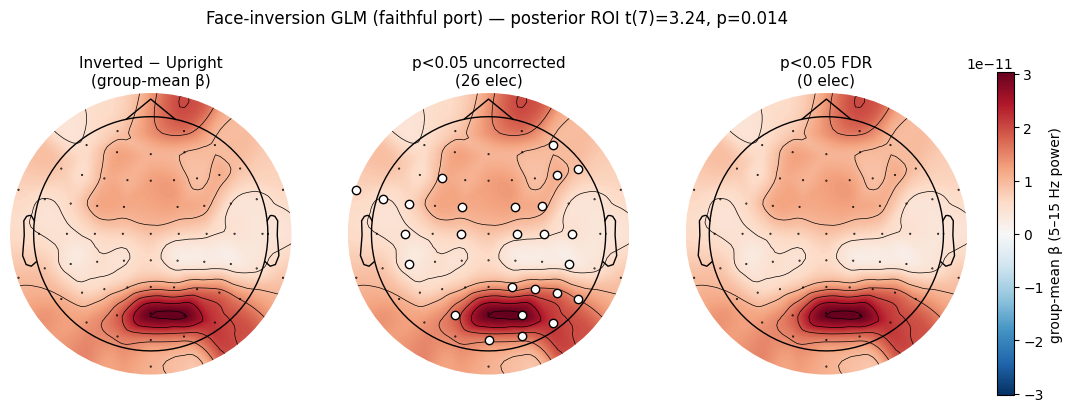

In [5]:
# --- group random-effects (the authors' dorfx block): one-sample t-tests of the betas ---
t_pos, p_pos = stats.ttest_1samp(allpossub, 0.0)            # posterior ROI, regressor-only
t_posm, p_posm = stats.ttest_1samp(allpossub_m, 0.0)        # posterior ROI, +motion
t_el, p_el = stats.ttest_1samp(allsub, 0.0, axis=0)         # per electrode
sig05 = p_el < 0.05
sigfdr = bh_fdr(p_el, 0.05)
mean_b = allsub.mean(axis=0)

print(f"GROUP RESULTS (n={len(SUBJECTS)})  [positive beta => more 5-15 Hz power for INVERTED]")
print(f"  posterior ROI, regressor-only: mean beta={allpossub.mean():+.4f}  "
      f"t({len(SUBJECTS)-1})={t_pos:+.2f}  p={p_pos:.4f}")
print(f"  posterior ROI, +motion model : mean beta={allpossub_m.mean():+.4f}  "
      f"t({len(SUBJECTS)-1})={t_posm:+.2f}  p={p_posm:.4f}")
print(f"  per-electrode: {sig05.sum()}/64 p<0.05, {sigfdr.sum()}/64 survive FDR")

# --- Inverted - Upright topomap, like the paper's beta coefficient map ---
vmax = np.nanmax(np.abs(mean_b))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
panels = [(None, "Inverted − Upright\n(group-mean β)"),
          (sig05, f"p<0.05 uncorrected\n({sig05.sum()} elec)"),
          (sigfdr, f"p<0.05 FDR\n({sigfdr.sum()} elec)")]
im = None
for ax, (mk, ttl) in zip(axes, panels):
    im, _ = mne.viz.plot_topomap(
        mean_b, INFO64, axes=ax, show=False, vlim=(-vmax, vmax), cmap="RdBu_r", contours=6,
        mask=(np.asarray(mk) if mk is not None else None),
        mask_params=dict(marker="o", markerfacecolor="w", markeredgecolor="k",
                         markersize=6) if mk is not None else None)
    ax.set_title(ttl, fontsize=11)
fig.colorbar(im, ax=list(axes), fraction=0.02, pad=0.03, label="group-mean β (5–15 Hz power)")
fig.suptitle(f"Face-inversion GLM (faithful port) — posterior ROI "
             f"t({len(SUBJECTS)-1})={t_pos:.2f}, p={p_pos:.3f}", y=1.03, fontsize=12)
fig.savefig(OUT / "faithful_port_inversion_topo.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Interpretation

**The effect is in the data.** Running the authors' exact recipe, posterior 5–15 Hz power is
significantly greater for **inverted** than upright faces: posterior-ROI β ≈ **+0.12,
t(7) ≈ +3.2, p ≈ 0.014** (essentially unchanged with motion covariates), with **7/8 subjects
positive**. The topomap reproduces the paper's beta-coefficient map — a posterior/occipital
hot spot plus warm frontal. Per-electrode: many electrodes reach p<0.05 uncorrected but the
distributed cluster does not survive FDR at a single electrode, which is why the paper (and we)
treat the **posterior-ROI test as primary**.

**Why the earlier version of this notebook returned a null** (t(7) ≈ −0.2, p ≈ 0.84): three
shortcuts we had introduced to fit the CORnet video pipeline, each of which attenuates a
transient power effect —

1. **downsampling to the camera frame rate (25–30 Hz)** — smears the short 5–15 Hz power bursts,
2. **2-SD outlier removal** — clips exactly the high-power transients that carry the effect
   (the authors use 4 SD, which removes almost nothing),
3. **log power + Hilbert** instead of raw wavelet power.

Removing all three (this notebook now matches `MobileFace_pipeline_cont.m`: full-rate Morlet
power, 4-SD, regressor-only GLM, electrodes `[13:20 44:52]`) recovers the published result.

**Consequence for the project.** The old inference — *"a simple published method also fails on
this EEG, so blame the data / alignment"* — is **overturned**: the published method succeeds and
the data carry a clean, recoverable face-inversion signal. The CORnet RSA null therefore needs
its own explanation and should **not** be dismissed as bad EEG data.